In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle
import os

# Load cleaned data
labeled = pd.read_pickle('../data/processed/labeled_wafers.pkl')
print(f"Loaded {len(labeled):,} wafers")
print(labeled['failureType'].value_counts())

Loaded 172,948 wafers
failureType
none         147429
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [2]:
le = LabelEncoder()
labeled['label_encoded'] = le.fit_transform(labeled['failureType'])

# Save label encoder for inference later
with open('../data/processed/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Class → Integer mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

NUM_CLASSES = len(le.classes_)
print(f"\nTotal classes: {NUM_CLASSES}")

Class → Integer mapping:
  0: Center
  1: Donut
  2: Edge-Loc
  3: Edge-Ring
  4: Loc
  5: Near-full
  6: Random
  7: Scratch
  8: none

Total classes: 9


In [3]:
# Stratified split to preserve class ratios
train_df, temp_df = train_test_split(
    labeled,
    test_size=0.2,
    stratify=labeled['label_encoded'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label_encoded'],
    random_state=42
)

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"\nTrain class distribution:")
print(train_df['failureType'].value_counts())

# Save splits
train_df.to_pickle('../data/processed/train.pkl')
val_df.to_pickle('../data/processed/val.pkl')
test_df.to_pickle('../data/processed/test.pkl')
print("\nSplits saved.")

Train: 138,358  |  Val: 17,295  |  Test: 17,295

Train class distribution:
failureType
none         117943
Edge-Ring      7744
Edge-Loc       4151
Center         3435
Loc            2874
Scratch         955
Random          693
Donut           444
Near-full       119
Name: count, dtype: int64

Splits saved.


In [4]:
# Stratified split to preserve class ratios
train_df, temp_df = train_test_split(
    labeled,
    test_size=0.2,
    stratify=labeled['label_encoded'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label_encoded'],
    random_state=42
)

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"\nTrain class distribution:")
print(train_df['failureType'].value_counts())

# Save splits
train_df.to_pickle('../data/processed/train.pkl')
val_df.to_pickle('../data/processed/val.pkl')
test_df.to_pickle('../data/processed/test.pkl')
print("\nSplits saved.")

Train: 138,358  |  Val: 17,295  |  Test: 17,295

Train class distribution:
failureType
none         117943
Edge-Ring      7744
Edge-Loc       4151
Center         3435
Loc            2874
Scratch         955
Random          693
Donut           444
Near-full       119
Name: count, dtype: int64

Splits saved.


In [5]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label_encoded'].values
)

class_weights_tensor = torch.FloatTensor(class_weights)

print("Class weights (higher = rarer class):")
for i, (cls, w) in enumerate(zip(le.classes_, class_weights)):
    print(f"  {cls:12s}: {w:.4f}")

# Save weights
torch.save(class_weights_tensor, '../data/processed/class_weights.pt')
print("\nClass weights saved.")

Class weights (higher = rarer class):
  Center      : 4.4754
  Donut       : 34.6241
  Edge-Loc    : 3.7035
  Edge-Ring   : 1.9852
  Loc         : 5.3490
  Near-full   : 129.1858
  Random      : 22.1834
  Scratch     : 16.0975
  none        : 0.1303

Class weights saved.


In [6]:
TARGET_SIZE = 64

class WaferDataset(Dataset):
    def __init__(self, dataframe, transform=None, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.augment = augment
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wafer = row['waferMap'].astype(np.float32)
        label = int(row['label_encoded'])
        
        # Resize to TARGET_SIZE x TARGET_SIZE
        img = Image.fromarray(wafer)
        img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.NEAREST)
        wafer_resized = np.array(img)
        
        # Normalize: 0=background, 1=good die, 2=defect → scale to [0,1]
        wafer_norm = wafer_resized / 2.0
        
        # Convert to 3-channel tensor (repeat across channels for ResNet compatibility)
        tensor = torch.FloatTensor(wafer_norm).unsqueeze(0)  # (1, 64, 64)
        tensor = tensor.repeat(3, 1, 1)                       # (3, 64, 64)
        
        if self.transform:
            tensor = self.transform(tensor)
            
        return tensor, label

print("WaferDataset class defined.")

WaferDataset class defined.


In [7]:
# Augmentation for training (helps with rare classes)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=30),
])

# No augmentation for val/test
eval_transform = None

# Build datasets
train_dataset = WaferDataset(train_df, transform=train_transform, augment=True)
val_dataset   = WaferDataset(val_df,   transform=eval_transform)
test_dataset  = WaferDataset(test_df,  transform=eval_transform)

# Build dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 2162
Val batches:   271
Test batches:  271


Batch shape: torch.Size([64, 3, 64, 64])
Label sample: [8, 8, 2, 8, 8, 8, 8, 2]


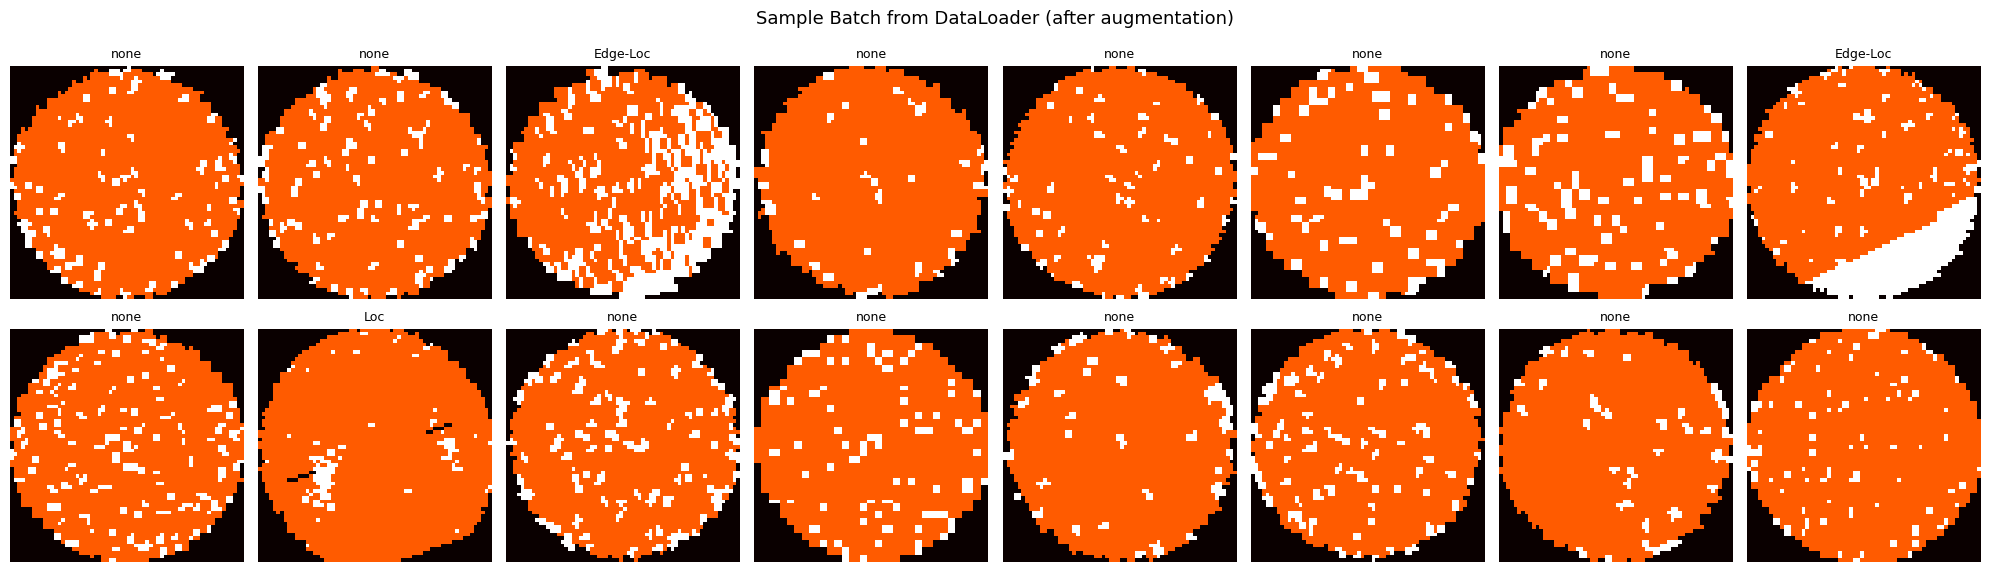

In [8]:
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # Should be (64, 3, 64, 64)
print(f"Label sample: {labels[:8].tolist()}")

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i in range(8):
    # Show channel 0 (all channels are identical)
    axes[0][i].imshow(images[i][0].numpy(), cmap='hot')
    axes[0][i].set_title(le.classes_[labels[i]], fontsize=9)
    axes[0][i].axis('off')
    
    axes[1][i].imshow(images[i+8][0].numpy(), cmap='hot')
    axes[1][i].set_title(le.classes_[labels[i+8]], fontsize=9)
    axes[1][i].axis('off')

plt.suptitle('Sample Batch from DataLoader (after augmentation)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/sample_batch.png', dpi=150)
plt.show()

Everything is working perfectly! Here's what stands out:

* Batch shape (64, 3, 64, 64) ✅ — ready for ResNet
* Splits are clean: 138K train / 17K val / 17K test ✅
* Class weights are dramatic — Near-full = 129.19 vs none = 0.13 — that's a 992× difference, which is why weighted loss is non-negotiable
* The batch is mostly none (label 8) which is expected given 85% dominance